In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
raw_data = Path('raw/')
exp1 = pd.read_csv(raw_data / "experiment1.csv")
exp_lin  = exp1[exp1['surface'] == 'linoleum']
exp_gr   = exp1[exp1['surface'] == 'grass']
exp_rub  = exp1[exp1['surface'] == 'rubber_carpet']
exp_cell = exp1[exp1['surface'] == 'cell_carpet']

In [4]:
exp_lin.head()

,surface,velocity,target_angle,time,aruco_x,aruco_y,aruco_theta,x,y,theta,odom_x,odom_y,odom_theta,x_loc,y_loc,theta_loc,wheel_joint_fl,wheel_joint_fr,wheel_joint_bl,wheel_joint_br
0,linoleum,0.2,0.0,0.199985,-0.653427,-0.322973,0.401330,0.003097,0.002691,0.042079,-0.320698,0.195687,-0.097326,0.000000,0.000000,0.000000,-0.083,-0.013,0.090,-0.101
1,linoleum,0.2,0.0,0.399957,-0.651935,-0.322785,0.383882,0.004589,0.002878,0.024631,-0.304100,0.192326,-0.097230,0.016598,-0.003360,0.000096,-0.584,0.587,-0.363,0.359
2,linoleum,0.2,0.0,0.600063,-0.656524,-0.325663,0.359251,0.000000,0.000000,0.000000,-0.265416,0.184529,-0.097453,0.055282,-0.011157,-0.000127,-0.317,0.213,-0.104,0.137
3,linoleum,0.2,0.0,0.800011,-0.657456,-0.325482,0.810945,-0.000932,0.000181,0.451694,-0.225949,0.176719,-0.097593,0.094748,-0.018968,-0.000267,-0.235,0.238,-0.099,0.229
4,linoleum,0.2,0.0,0.999988,-0.657410,-0.325840,-0.415720,-0.000887,-0.000177,-0.774972,-0.184367,0.168526,-0.097788,0.136330,-0.027161,-0.000462,-0.281,0.145,-0.101,0.075


In [5]:
exp_gr.head()

,surface,velocity,target_angle,time,aruco_x,aruco_y,aruco_theta,x,y,theta,odom_x,odom_y,odom_theta,x_loc,y_loc,theta_loc,wheel_joint_fl,wheel_joint_fr,wheel_joint_bl,wheel_joint_br
1447,grass,0.2,0.0,0.199557,-0.519581,-0.035022,0.326193,-0.00074,0.000023,-0.028356,-0.088453,-0.002334,0.005873,7.134023e-07,7.303614e-07,9.375574e-07,0.062,0.252,0.098,0.531
1448,grass,0.2,0.0,0.399534,-0.519581,-0.035022,0.326193,-0.00074,0.000023,-0.028356,-0.071025,-0.002006,0.006479,1.742837e-02,3.288270e-04,6.065985e-04,-1.122,1.372,-0.937,1.465
1449,grass,0.2,0.0,0.599550,-0.519581,-0.035022,0.326193,-0.00074,0.000023,-0.028356,-0.039794,-0.002153,0.008452,4.865997e-02,1.816581e-04,2.580136e-03,-0.679,0.998,-0.776,0.846
1450,grass,0.2,0.0,0.799566,-0.519581,-0.035022,0.326193,-0.00074,0.000023,-0.028356,-0.002853,-0.001709,0.010056,8.560085e-02,6.258875e-04,4.184255e-03,-0.528,0.859,-0.611,1.017
1451,grass,0.2,0.0,0.999542,-0.519581,-0.035022,0.326193,-0.00074,0.000023,-0.028356,0.027942,-0.001862,0.012226,1.163956e-01,4.734518e-04,6.353665e-03,-0.800,0.744,-0.465,0.847


In [6]:
exp_rub.head()

,surface,velocity,target_angle,time,aruco_x,aruco_y,aruco_theta,x,y,theta,odom_x,odom_y,odom_theta,x_loc,y_loc,theta_loc,wheel_joint_fl,wheel_joint_fr,wheel_joint_bl,wheel_joint_br
2799,rubber_carpet,0.2,0.0,0.200126,-0.303281,-0.169115,0.709750,0.527908,0.311361,0.954289,-0.008670,-0.074301,0.006876,0.000001,0.000001,0.000002,1.526,1.601,-1.619,-1.967
2800,rubber_carpet,0.2,0.0,0.399841,-0.825111,-0.477575,-0.251548,0.006078,0.002902,-0.007010,0.008171,-0.071534,0.006887,0.016842,0.002768,0.000013,0.125,2.331,-2.372,-0.538
2801,rubber_carpet,0.2,0.0,0.599777,-0.831710,-0.481115,-0.234677,-0.000521,-0.000639,0.009861,0.037687,-0.065575,0.007392,0.046358,0.008727,0.000518,0.346,2.276,-2.103,-0.467
2802,rubber_carpet,0.2,0.0,0.799730,-0.831189,-0.480477,-0.244539,0.000000,0.000000,0.000000,0.072009,-0.061041,0.006760,0.080680,0.013262,-0.000114,0.160,1.804,-2.016,-0.697
2803,rubber_carpet,0.2,0.0,0.999797,-0.831189,-0.480477,-0.244539,0.000000,0.000000,0.000000,0.108058,-0.055564,0.005865,0.116729,0.018739,-0.001009,0.261,2.031,-1.981,-0.534


In [7]:
exp_cell.head()

,surface,velocity,target_angle,time,aruco_x,aruco_y,aruco_theta,x,y,theta,odom_x,odom_y,odom_theta,x_loc,y_loc,theta_loc,wheel_joint_fl,wheel_joint_fr,wheel_joint_bl,wheel_joint_br
4305,cell_carpet,0.2,0.0,0.200011,-0.893880,-0.014745,-0.595137,0.006125,0.001083,-0.365409,-0.042857,-0.346338,-0.002778,-7.259316e-07,-7.179094e-07,-9.375699e-07,0.301,-0.183,0.097,-0.264
4306,cell_carpet,0.2,0.0,0.399739,-0.893880,-0.014745,-0.595137,0.006125,0.001083,-0.365409,-0.024090,-0.346413,-0.003054,1.876650e-02,-7.579396e-05,-2.765830e-04,-0.566,0.749,-0.736,0.693
4307,cell_carpet,0.2,0.0,0.599762,-0.893880,-0.014745,-0.595137,0.006125,0.001083,-0.365409,0.009957,-0.346330,-0.003097,5.281397e-02,6.465870e-06,-3.197112e-04,-0.201,0.362,-0.421,0.280
4308,cell_carpet,0.2,0.0,0.799761,-0.900005,-0.015828,-0.229728,0.000000,0.000000,0.000000,0.046793,-0.346527,-0.003079,8.965002e-02,-1.897650e-04,-3.018974e-04,-0.338,0.398,-0.444,0.343
4309,cell_carpet,0.2,0.0,0.999716,-0.890321,-0.014429,0.309901,0.009684,0.001399,0.539629,0.083705,-0.346502,-0.003220,1.265618e-01,-1.649529e-04,-4.425327e-04,-0.241,0.435,-0.408,0.282


In [8]:
exp1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5381 entries, 0 to 5380
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   surface         5381 non-null   object 
 1   velocity        5381 non-null   float64
 2   target_angle    5381 non-null   float64
 3   time            5381 non-null   float64
 4   aruco_x         5381 non-null   float64
 5   aruco_y         5381 non-null   float64
 6   aruco_theta     5381 non-null   float64
 7   x               5381 non-null   float64
 8   y               5381 non-null   float64
 9   theta           5381 non-null   float64
 10  odom_x          5381 non-null   float64
 11  odom_y          5381 non-null   float64
 12  odom_theta      5381 non-null   float64
 13  x_loc           5381 non-null   float64
 14  y_loc           5381 non-null   float64
 15  theta_loc       5381 non-null   float64
 16  wheel_joint_fl  5381 non-null   float64
 17  wheel_joint_fr  5381 non-null   f

In [9]:
# Темные цвета
dark_colors = [
    "#912A1E",  # Темно-красный
    "#502563",  # Темно-фиолетовый
    "#176136",  # Темно-зеленый
    "#D35400",  # Темно-оранжевый
    "#CF9801",  # Темно-горчичный
    "#750B2E",  # Темно-розовый
    "#C62828",  # Темно-красный/бордовый
    "#066388",  # Темно-голубой
    "#0E6B58",  # Темно-бирюзовый
    "#8E44AD",  # Темно-фиолетовый
    "#2E3A4D",  # Темно-синий
    "#4A2C2A",  # Темно-коричневый
]

# Светлые цвета
light_colors = [
    "#FF8D74",  # Ярко-красный
    "#AF79C4",  # Светло-фиолетовый
    "#61CF8F",  # Ярко-зеленый
    "#E67E22",  # Ярко-оранжевый
    "#F1C40F",  # Ярко-желтый
    "#FA335E",  # Светло-розовый
    "#E6887E",  # Ярко-красный/бордовый
    "#32F3E9",  # Ярко-голубой
    "#1ABC9C",  # Ярко-бирюзовый
    "#B673D1",  # Светло-фиолетовый
    "#4A90E2",  # Ярко-синий
    "#97744C",  # Ярко-коричневый
]

['linoleum' 'grass' 'rubber_carpet' 'cell_carpet']
[ 0.         -3.14159265  0.08726646 -3.05432619  0.17453293 -2.96705973
  0.26179939 -2.87979327  0.34906585 -2.7925268   0.43633231 -2.70526034
  0.52359878 -2.61799388  0.61086524 -2.53072742  0.6981317  -2.44346095
  0.78539816 -2.35619449  0.87266463 -2.26892803  0.95993109 -2.18166156
  1.04719755 -2.0943951   1.13446401 -2.00712864  1.22173048 -1.91986218
  1.30899694 -1.83259571  1.3962634  -1.74532925  1.48352986 -1.65806279
  1.57079633 -1.57079633  1.65806279 -1.48352986  1.74532925 -1.3962634
  1.83259571 -1.30899694  1.91986218 -1.22173048  2.00712864 -1.13446401
  2.0943951  -1.04719755  2.18166156 -0.95993109  2.26892803 -0.87266463
  2.35619449 -0.78539816  2.44346095 -0.6981317   2.53072742 -0.61086524
  2.61799388 -0.52359878  2.70526034 -0.43633231  2.7925268  -0.34906585
  2.87979327 -0.26179939  3.05432619  2.96705973 -0.17453293 -0.08726646]


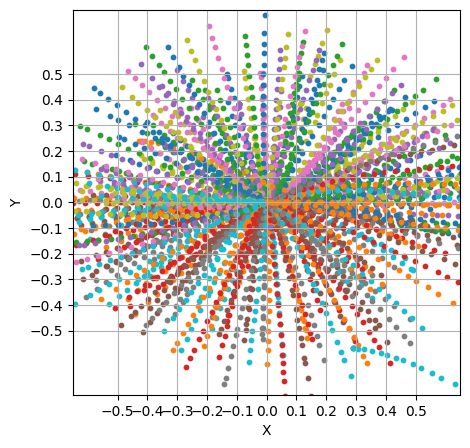

In [10]:
plt.figure(figsize=(5, 5))
angles = exp1['target_angle'].unique()
surfaces = exp1['surface'].unique()
print(surfaces)
print(angles)
i = 0
for angle in angles:
    x0 = exp1['x_loc'].loc[(exp1['target_angle'] == angle) & (exp1['surface'] == 'grass')]
    y0 = exp1['y_loc'].loc[(exp1['target_angle'] == angle) & (exp1['surface'] == 'grass')]
    rt_ang = 0
    x = x0 * math.cos(rt_ang) - y0 * math.sin(rt_ang)
    y = x0 * math.sin(rt_ang) + y0 * math.cos(rt_ang)
    # plt.scatter(x, -y, s=10, c=dark_colors[i]) , c=light_colors[i]
    plt.scatter(exp1['x_loc'].loc[exp1['target_angle'] == angle], exp1['y_loc'].loc[exp1['target_angle'] == angle], s=10)
    i += 1
plt.xlabel('X')
plt.ylabel('Y')
plt.xticks(np.arange(-0.5, 0.6, 0.1))
plt.yticks(np.arange(-0.5, 0.6, 0.1))
plt.xlim(-0.65, 0.65)
plt.ylim(-0.75, 0.75)
plt.grid()
plt.show()

In [11]:
x0 = exp1['x_loc']
x0.info()

angles = exp1['target_angle'].unique()
angles.sort()
angles_deg = np.rad2deg(angles)
print(angles)
print(angles_deg)

<class 'pandas.core.series.Series'>
RangeIndex: 5381 entries, 0 to 5380
Series name: x_loc
Non-Null Count  Dtype  
--------------  -----  
5381 non-null   float64
dtypes: float64(1)
memory usage: 42.2 KB
[-3.14159265 -3.05432619 -2.96705973 -2.87979327 -2.7925268  -2.70526034
 -2.61799388 -2.53072742 -2.44346095 -2.35619449 -2.26892803 -2.18166156
 -2.0943951  -2.00712864 -1.91986218 -1.83259571 -1.74532925 -1.65806279
 -1.57079633 -1.48352986 -1.3962634  -1.30899694 -1.22173048 -1.13446401
 -1.04719755 -0.95993109 -0.87266463 -0.78539816 -0.6981317  -0.61086524
 -0.52359878 -0.43633231 -0.34906585 -0.26179939 -0.17453293 -0.08726646
  0.          0.08726646  0.17453293  0.26179939  0.34906585  0.43633231
  0.52359878  0.61086524  0.6981317   0.78539816  0.87266463  0.95993109
  1.04719755  1.13446401  1.22173048  1.30899694  1.3962634   1.48352986
  1.57079633  1.65806279  1.74532925  1.83259571  1.91986218  2.00712864
  2.0943951   2.18166156  2.26892803  2.35619449  2.44346095  2.53

Зависимость координат от времени движения
Максимальное изменение координат в зависимости от угла

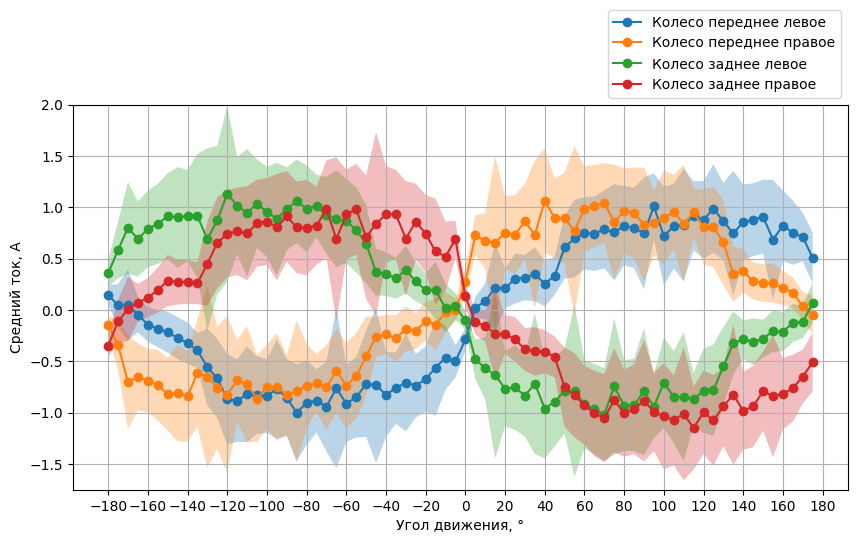

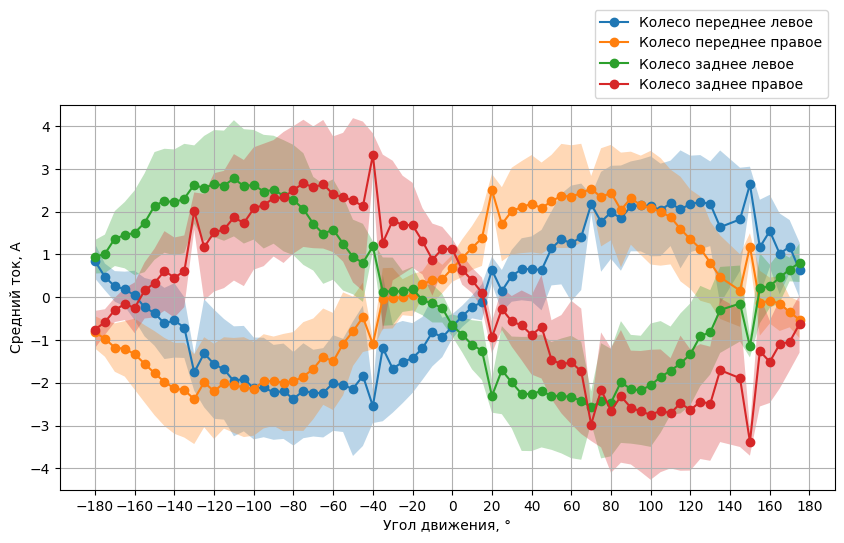

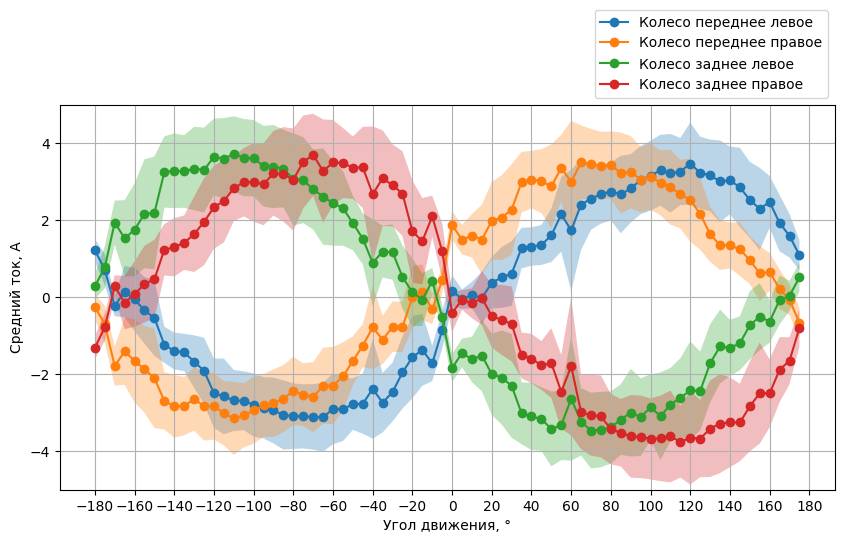

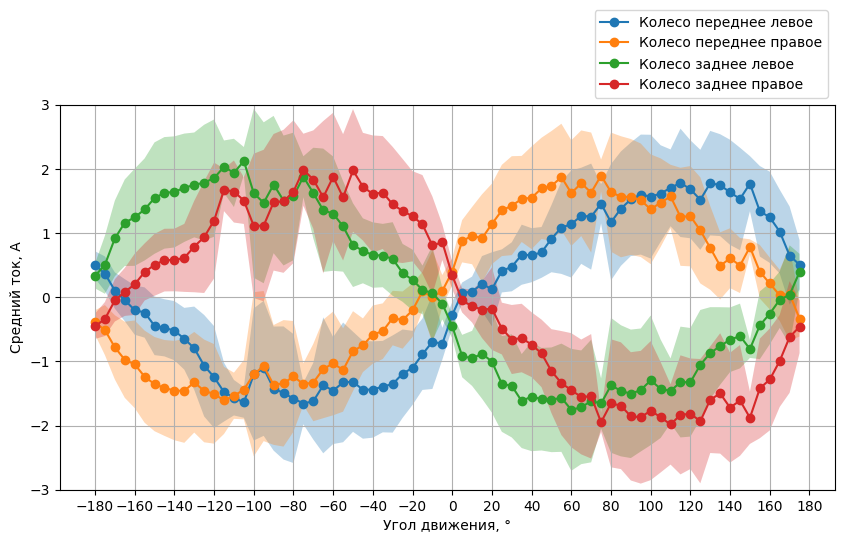

In [23]:
wheels_list = ['wheel_joint_fl', 'wheel_joint_fr', 'wheel_joint_bl', 'wheel_joint_br']
labels = ['Колесо переднее левое', 'Колесо переднее правое', 'Колесо заднее левое', 'Колесо заднее правое']

def currentByAngPlot(exp_df, ymin, ymax):
    koeff_torq = 0.87

    grouped = exp_df.groupby('target_angle')[wheels_list].mean().reset_index()
    
    grouped_std = exp_df.groupby('target_angle')[wheels_list].std().reset_index()

    grouped['angle_deg'] = np.degrees(grouped['target_angle'])
    grouped_std['angle_deg'] = np.degrees(grouped_std['target_angle'])

    plt.figure(figsize=(10, 5))
    for wheel, label in zip(wheels_list, labels):
        plt.plot(grouped['angle_deg'], grouped[wheel]/koeff_torq, marker='o', label=label)

        plt.fill_between(grouped_std['angle_deg'],
                     (grouped[wheel] - grouped_std[wheel])/koeff_torq, 
                     (grouped[wheel] + grouped_std[wheel])/koeff_torq, 
                     alpha=0.3)
    

    plt.xticks(np.arange(-180, 200, step=20))
    plt.ylim(ymin, ymax)

    plt.xlabel('Угол движения, °')
    plt.ylabel('Средний ток, A')

    plt.grid(True)
    plt.legend(loc='lower right', bbox_to_anchor=(1, 1))
    plt.show()

currentByAngPlot(exp_lin, -1.75, 2)
currentByAngPlot(exp_gr, -4.5, 4.5)
currentByAngPlot(exp_rub, -5, 5)
currentByAngPlot(exp_cell, -3, 3)

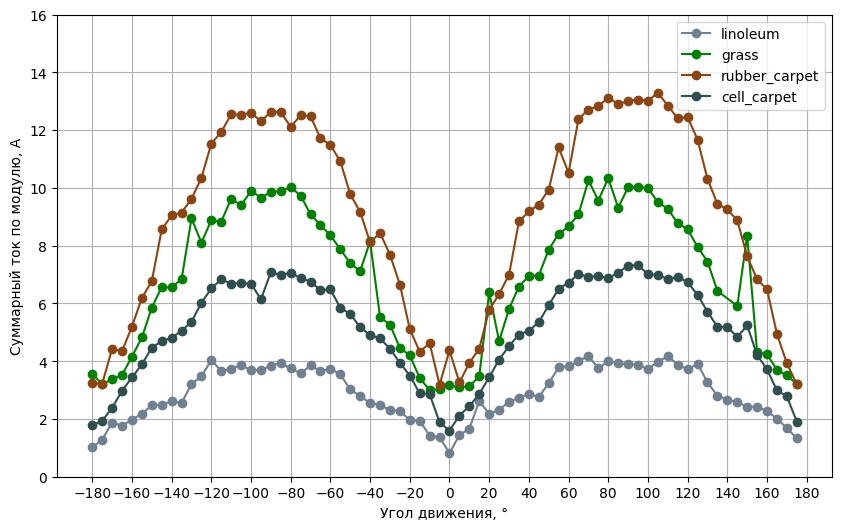

In [13]:
def currentByAng(exp_df, label, color):
    exp_df = exp_df.copy()

    koeff_torq = 0.87

    exp_df['total_effort'] = (
        abs(exp_df['wheel_joint_fl']) +
        abs(exp_df['wheel_joint_fr']) +
        abs(exp_df['wheel_joint_bl']) +
        abs(exp_df['wheel_joint_br'])
    )

    grouped = exp_df.groupby('target_angle')['total_effort'].mean().reset_index()

    grouped['angle_deg'] = np.degrees(grouped['target_angle'])

    plt.plot(grouped['angle_deg'], grouped['total_effort']/koeff_torq, marker='o', label=label, color=color)

plt.figure(figsize=(10, 6))

currentByAng(exp_lin, 'linoleum', 'slategray')
currentByAng(exp_gr, 'grass', 'green')
currentByAng(exp_rub, 'rubber_carpet', 'saddlebrown')
currentByAng(exp_cell, 'cell_carpet', 'darkslategray')

plt.xticks(np.arange(-180, 200, step=20))

plt.ylim(0, 16)

plt.xlabel('Угол движения, °')
plt.ylabel('Суммарный ток по модулю, A')

plt.grid(True)
plt.legend(loc='upper right')
plt.show()


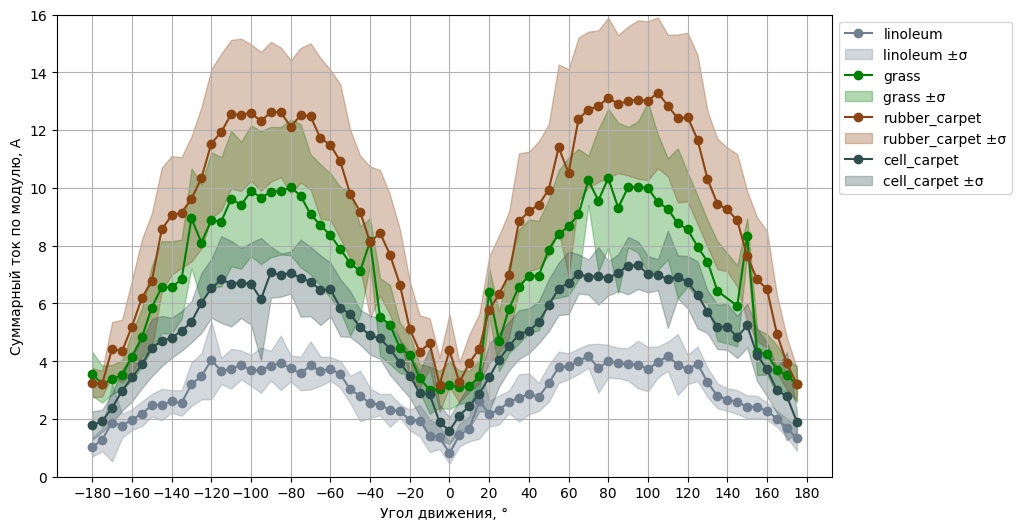

In [14]:
def currentByAng(exp_df, label, color):
    exp_df = exp_df.copy()

    koeff_torq = 0.87

    exp_df['total_effort'] = (
        abs(exp_df['wheel_joint_fl']) +
        abs(exp_df['wheel_joint_fr']) +
        abs(exp_df['wheel_joint_bl']) +
        abs(exp_df['wheel_joint_br'])
    )

    grouped = exp_df.groupby('target_angle')['total_effort'].mean().reset_index()

    grouped_std = exp_df.groupby('target_angle')['total_effort'].std().reset_index()

    grouped['angle_deg'] = np.degrees(grouped['target_angle'])
    grouped_std['angle_deg'] = np.degrees(grouped_std['target_angle'])

    plt.plot(grouped['angle_deg'], grouped['total_effort']/koeff_torq, marker='o', label=label, color=color)
    plt.fill_between(grouped_std['angle_deg'],
                     (grouped['total_effort'] - grouped_std['total_effort'])/koeff_torq, 
                     (grouped['total_effort'] + grouped_std['total_effort'])/koeff_torq, 
                     alpha=0.3, label=label+' ±σ', color=color)

plt.figure(figsize=(10, 6))

currentByAng(exp_lin, 'linoleum', 'slategray')
currentByAng(exp_gr, 'grass', 'green')
currentByAng(exp_rub, 'rubber_carpet', 'saddlebrown')
currentByAng(exp_cell, 'cell_carpet', 'darkslategray')

plt.xticks(np.arange(-180, 200, step=20))

plt.ylim(0, 16)

plt.xlabel('Угол движения, °')
plt.ylabel('Суммарный ток по модулю, A')

plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()
